# SentinelSat
 - [GitHub](https://github.com/sentinelsat/sentinelsat)
 - [ReadTheDocs](https://sentinelsat.readthedocs.io/en/stable/api_overview.html#lta-products)
 

### Load

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# %load import.py
# 
import numpy as np
import pandas as pd

#
from sentinelsat import SentinelAPI, read_geojson, geojson_to_wkt
from datetime import date

#
import rioxarray
import geopandas as gpd
import rasterio as rio

#
from matplotlib import pyplot
from rasterio.plot import show

#
from sqlalchemy import create_engine # query PostGIS
from sqlalchemy import inspect

#
import osmnx as ox

#
from shapely.geometry import Polygon, box
import shapely.ops as so

#
import json

#
import os
from pathlib import Path
import fnmatch
import glob

#
from osgeo import gdal

#
import random

#
import shutil

#
from tqdm import tqdm
import time

## Study Area

In [8]:
# sa_fil = "italy_center_south.geojson"
sa_fil = "naples_metropolytan.geojson"

In [9]:
sa_j = read_geojson(sa_fil)

In [34]:
type(sa_j)

geojson.feature.FeatureCollection

In [10]:
sa = geopandas.read_file(sa_fil)

In [36]:
type(sa)

geopandas.geodataframe.GeoDataFrame

<Axes: >

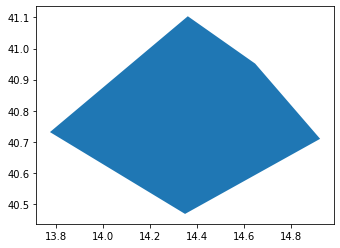

In [37]:
sa.plot()

### Geospatial raster and Vector data with Python

 - [EGU short course 2023](https://github.com/esciencecenter-digital-skills/2023-04-25-ds-geospatial-python-EGU)

### Check out `RapidEye time series for Sentinel-2`

 - [ESA link](https://earth.esa.int/eogateway/catalog/rapideye-time-series-for-sentinel-2)

## PROCEDURE

### Credentials / API

In [110]:
from impervious.config import settings  # credenziali da .env

In [115]:
# Opening JSON file
# credenziali ora da .env (impervious.config); vecchio load JSON disattivato
# sensat = json.load(json_file)
 
    # Print the type of data variable
#    print("Type:", type(data))
 
    # Print the data of dictionary
#    print("\nUser      :", data['user'])
#    print("\nPassword  :", data['password'])

In [116]:
user = settings.scihub_user
pswd = settings.scihub_password
sentinelSat_endpoint = "https://apihub.copernicus.eu/apihub"

In [117]:
api = SentinelAPI(user, pswd, sentinelSat_endpoint)

In [118]:
api.session

### Request Sat Products

In [119]:
date_FROM = date(2023,4,1)
date_TO   = date(2023,5,1)

In [120]:
platform_name = "Sentinel-2"

In [121]:
cloud_coverage = (0,10)

In [122]:
# search by polygon, time, and SciHub query keywords
products = api.query( geojson_to_wkt(sa_j),
                      date = ( date_FROM, date_TO ),
                      platformname = platform_name,
                      cloudcoverpercentage = cloud_coverage
                    )

In [123]:
len(products)

11

### GeoDataFrame from Products

In [19]:
gdf = api.to_geodataframe(products)

In [20]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [21]:
gdf.head(1)

,title,link,link_alternative,link_icon,summary,ondemand,datatakesensingstart,generationdate,beginposition,endposition,...,illuminationazimuthangle,illuminationzenithangle,vegetationpercentage,notvegetatedpercentage,waterpercentage,unclassifiedpercentage,mediumprobacloudspercentage,highprobacloudspercentage,snowicepercentage,geometry
248a17ee-f48b-4ea9-9b3b-4019387f1d05,S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_2...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,"Date: 2023-04-27T09:50:31.024Z, Instrument: MS...",false,2023-04-27 09:50:31.024,2023-04-27 11:50:04,2023-04-27 09:50:31.024,2023-04-27 09:50:31.024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((13.81838 40.55671, 15.11529 40..."


<Axes: >

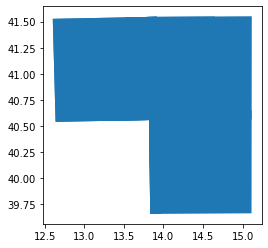

In [22]:
gdf.plot()

In [23]:
gdf.bounds

,minx,miny,maxx,maxy
248a17ee-f48b-4ea9-9b3b-4019387f1d05,13.800551,40.556707,15.117032,41.551785
d07d875f-3556-43bd-8d5a-1bf3eb3f3be2,13.214424,40.547153,13.934585,41.546759
534b7819-b821-4204-ba94-a717ee14f97b,13.816827,39.655753,15.115443,40.650799
d63bce7b-3e52-4bab-bb95-b4dc3c8b5b8c,13.816827,39.655753,14.323007,40.647135
c449fee8-d08f-4dc5-9043-e2e93d4f94d2,13.800551,40.556707,14.652539,41.549599
d33bc78f-bd67-458c-835f-52272276d3e4,12.602817,40.538608,13.934585,41.546759
279393d1-f67e-4e10-aa7f-247cc0cdf2f5,13.816827,39.655753,14.323007,40.647135
145cde7a-55b7-445a-a2a6-a4c358ab960d,12.602817,40.538608,13.934585,41.546759
f9f99c35-968b-4601-8e60-e4ec277f59d0,13.816827,40.038028,14.317916,40.647112
48b8068d-8fac-4ddf-9454-3d830fd227eb,13.212976,40.547132,13.934585,41.546759


### Select Products

Get the list of first 5 keys:

In [24]:
list(products.keys())[0:5]

['248a17ee-f48b-4ea9-9b3b-4019387f1d05',
 'd07d875f-3556-43bd-8d5a-1bf3eb3f3be2',
 '534b7819-b821-4204-ba94-a717ee14f97b',
 'd63bce7b-3e52-4bab-bb95-b4dc3c8b5b8c',
 'c449fee8-d08f-4dc5-9043-e2e93d4f94d2']

Select only the first product:

In [25]:
sel_products = dict(list(products.items())[:1])

In [26]:
api.get_product_odata( list(sel_products.keys())[0] )

{'id': '248a17ee-f48b-4ea9-9b3b-4019387f1d05',
 'title': 'S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004',
 'size': 822914014,
 'md5': 'a56725e3bffcf231cd9569dd62cc3841',
 'date': datetime.datetime(2023, 4, 27, 9, 50, 31, 24000),
 'footprint': 'POLYGON((13.800550898366621 41.54558876800179,15.117031634388816 41.55178511688993,15.115291564528247 40.5626923872254,13.818379707800878 40.556706911840905,13.800550898366621 41.54558876800179))',
 'url': "https://apihub.copernicus.eu/apihub/odata/v1/Products('248a17ee-f48b-4ea9-9b3b-4019387f1d05')/$value",
 'Online': True,
 'Creation Date': datetime.datetime(2023, 4, 27, 14, 50, 3, 256000),
 'Ingestion Date': datetime.datetime(2023, 4, 27, 14, 49, 35, 611000),
 'manifest_name': 'manifest.safe',
 'product_root_dir': 'S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004.SAFE',
 'quicklook_url': "https://apihub.copernicus.eu/apihub/odata/v1/Products('248a17ee-f48b-4ea9-9b3b-4019387f1d05')/Products('Quicklook')/$value"}

In [27]:
api.to_geodataframe(sel_products)

,title,link,link_alternative,link_icon,summary,ondemand,datatakesensingstart,generationdate,beginposition,endposition,...,producttype,platformidentifier,orbitdirection,platformserialidentifier,processinglevel,datastripidentifier,granuleidentifier,identifier,uuid,geometry
248a17ee-f48b-4ea9-9b3b-4019387f1d05,S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_2...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,https://apihub.copernicus.eu/apihub/odata/v1/P...,"Date: 2023-04-27T09:50:31.024Z, Instrument: MS...",false,2023-04-27 09:50:31.024,2023-04-27 11:50:04,2023-04-27 09:50:31.024,2023-04-27 09:50:31.024,...,S2MSI1C,2015-028A,DESCENDING,Sentinel-2A,Level-1C,S2A_OPER_MSI_L1C_DS_2APS_20230427T115004_S2023...,S2A_OPER_MSI_L1C_TL_2APS_20230427T115004_A0409...,S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_2...,248a17ee-f48b-4ea9-9b3b-4019387f1d05,"MULTIPOLYGON (((13.81838 40.55671, 15.11529 40..."


#### Save GeoDF

In [33]:
sel_prod_gdf = api.to_geodataframe(sel_products)

In [36]:
sel_prod_gdf.to_file("sel_products.geojson",driver="GeoJSON")

### Download Selected Products

In [28]:
# Activate only if required:
# api.download_all(sel_products,directory_path="data/")

### Map Selected Products

In [29]:
ras_path_20m = "data/S2A_MSIL1C_20230427T095031_N0509_R079_T33TVF_20230427T115004.SAFE/GRANULE/L1C_T33TVF_A040974_20230427T095813/IMG_DATA/"

In [30]:
raster = rioxarray.open_rasterio(ras_path_20m + "T33TVF_20230427T095031_TCI.jp2")

In [31]:
raster

<xarray.DataArray (band: 3, y: 10980, x: 10980)>
[361681200 values with dtype=uint8]
Coordinates:
  * band         (band) int64 1 2 3
  * x            (x) float64 4e+05 4e+05 4e+05 ... 5.097e+05 5.097e+05 5.098e+05
  * y            (y) float64 4.6e+06 4.6e+06 4.6e+06 ... 4.49e+06 4.49e+06
    spatial_ref  int64 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [32]:
raster.rio.crs

CRS.from_epsg(32633)

(array([1.61838800e+07, 7.79143090e+07, 1.89438079e+08, 5.01423410e+07,
        1.66188640e+07, 5.23070100e+06, 2.07601800e+06, 9.89229000e+05,
        6.48549000e+05, 2.43923000e+06]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

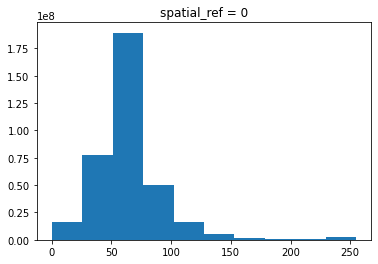

In [31]:
raster.plot()

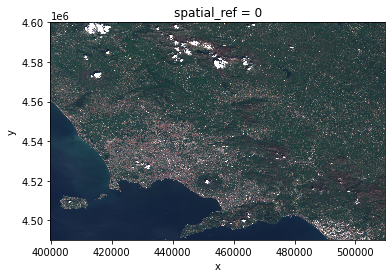

In [32]:
raster.plot.imshow()

### Get Sentinel-2 tiling grid

In [187]:
!wget https://sentinel.esa.int/documents/247904/1955685/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml

--2023-05-08 19:09:21--  https://sentinel.esa.int/documents/247904/1955685/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml
Resolving sentinel.esa.int (sentinel.esa.int)... 185.178.84.88
Connecting to sentinel.esa.int (sentinel.esa.int)|185.178.84.88|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 108817408 (104M) [application/vnd.google-earth.kml+xml]
Saving to: ‘S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml.1’

S2A_OPER_GIP_TILPAR 100%[===================>] 103.78M  3.03MB/s    in 36s     

2023-05-08 19:09:58 (2.85 MB/s) - ‘S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml.1’ saved [108817408/108817408]



In [188]:
s2_tile_grid = geopandas.read_file("S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml")

/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

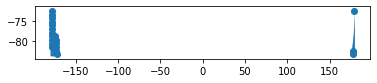

In [195]:
s2_tile_grid.head(20).plot()